In [2]:
%pip install pandas numpy matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Import necessary libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'svg'

print("Libraries imported successfully!")

# Connect to the SQLite database
conn = sqlite3.connect("inventory.db")

# Create a cursor object to interact with the database
cursor = conn.cursor()

# Function to run a SQL query and return the results as a DataFrame
def run_query_to_df(cursor, query):
    cursor.execute(query)
    rows = cursor.fetchall()
    
    # Get column names from cursor
    columns = []
    for col in cursor.description:
        columns.append(col[0])

    # Convert to DataFrame
    df = pd.DataFrame(rows, columns = columns)

    return df

Libraries imported successfully!


In [4]:
query = """
SELECT * FROM ORDERS
"""

# Call the function to run the query and display results
result = run_query_to_df(cursor, query)
result

,id,customer_id,product_id,order_date,quantity,profit_per_order,order_status
0,1,11599,957,1/1/2015 0:00,1,88.790001,CLOSED
1,2,256,403,1/1/2015 0:21,7,195.900002,PENDING_PAYMENT
2,4,8827,365,1/1/2015 1:03,14,124.090000,CLOSED
3,5,11318,365,1/1/2015 1:24,10,390.089995,COMPLETE
4,7,4530,926,1/1/2015 2:06,7,203.929998,COMPLETE
...,...,...,...,...,...,...,...
61139,77198,20751,1363,1/31/2018 21:32,1,70.510002,CLOSED
61140,77199,20752,1363,1/31/2018 21:53,1,103.589996,PENDING_PAYMENT
61141,77202,20755,1360,1/31/2018 22:56,1,91.250000,COMPLETE
61142,77203,20756,1361,1/31/2018 23:17,1,1.530000,PENDING_PAYMENT


In [6]:
#Only keeps category-region combinations with at least 10 orders, so the average delay is more reliable.
query = """
SELECT c.category_name, raw_import."Order Region" AS region, AVG(s.days_actual - s.days_scheduled) AS avg_delay, COUNT(o.id) AS number_of_orders
FROM orders AS o
JOIN shipping AS s
ON o.id = s.order_id
JOIN products AS p
ON o.product_id = p.id
JOIN categories AS c
ON p.category_id = c.id
JOIN raw_import
ON o.id = CAST(raw_import."Order Id" AS INTEGER)
GROUP BY c.category_name, raw_import."Order Region"
HAVING COUNT(o.id) >= 10 
ORDER BY avg_delay DESC
"""

result = run_query_to_df(cursor, query)
result["avg_delay"] = result["avg_delay"].round(2)
result

,category_name,region,avg_delay,number_of_orders
0,Girls' Apparel,Central Africa,2.20,15
1,Fitness Accessories,US Center,1.88,26
2,Trade-In,Eastern Europe,1.82,11
3,Lacrosse,Caribbean,1.80,35
4,Soccer,South America,1.75,40
...,...,...,...,...
580,Boxing & MMA,Eastern Europe,-0.56,18
581,Tennis & Racquet,South Asia,-0.56,32
582,Baseball & Softball,Southern Africa,-0.60,20
583,Women's Golf Clubs,Caribbean,-0.64,14


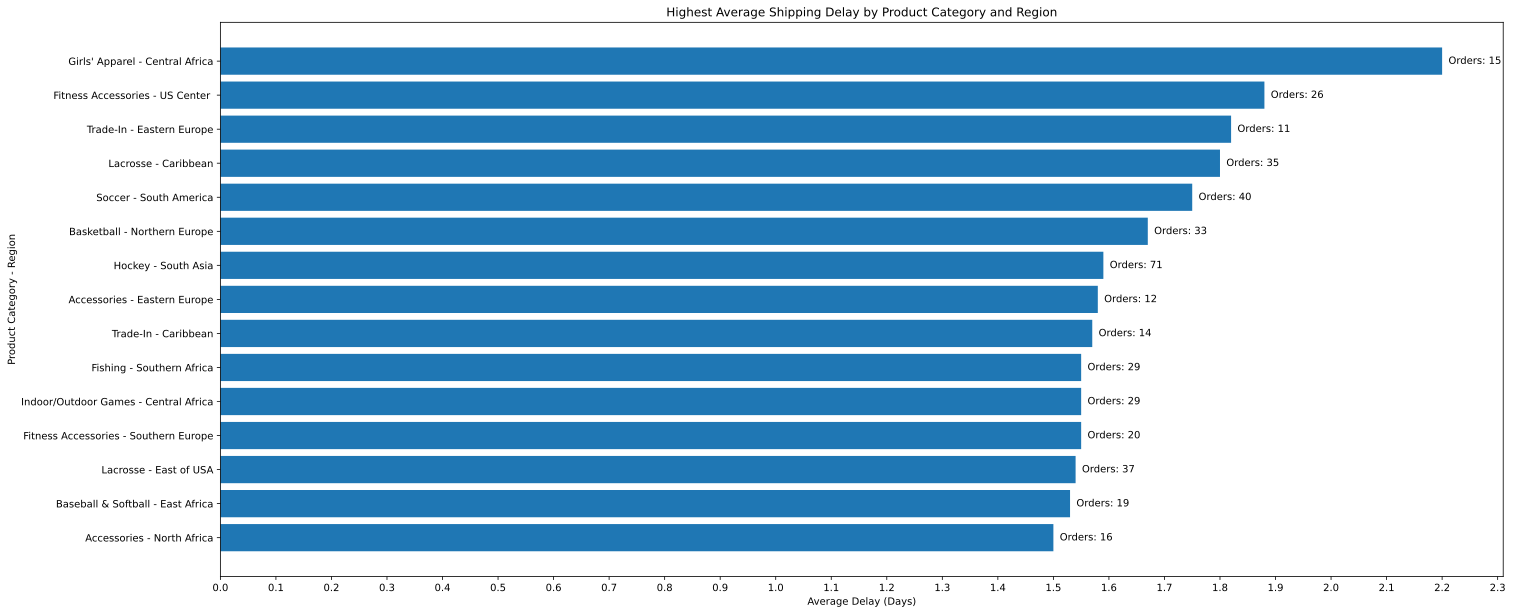

In [26]:
top = result.head(15)

top["combo"] = top["category_name"] + " - " + top["region"]

plt.figure(figsize=(23, 10))

bars = plt.barh(top["combo"], top["avg_delay"])

plt.xlabel("Average Delay (Days)")
plt.ylabel("Product Category - Region")
plt.title("Highest Average Shipping Delay by Product Category and Region")

for i in range(len(top)):
    plt.text(top["avg_delay"].iloc[i],
             i,
             "  Orders: " + str(top["number_of_orders"].iloc[i]),
             va="center")

plt.xticks(np.arange(0, 2.4, 0.1))

plt.gca().invert_yaxis()
plt.show()